In [2]:
# Fake & Real News Detector - Complete Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
# Load the dataset
print("Loading data...")
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

fake["label"] = 0
real["label"] = 1

data = pd.concat([fake, real], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total articles: {len(data)}")
print(f"Fake news articles: {len(fake)}")
print(f"Real news articles: {len(real)}")
print(f"\nDataset columns: {list(data.columns)}")
data.head()

Loading data...
Total articles: 44898
Fake news articles: 23481
Real news articles: 21417

Dataset columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


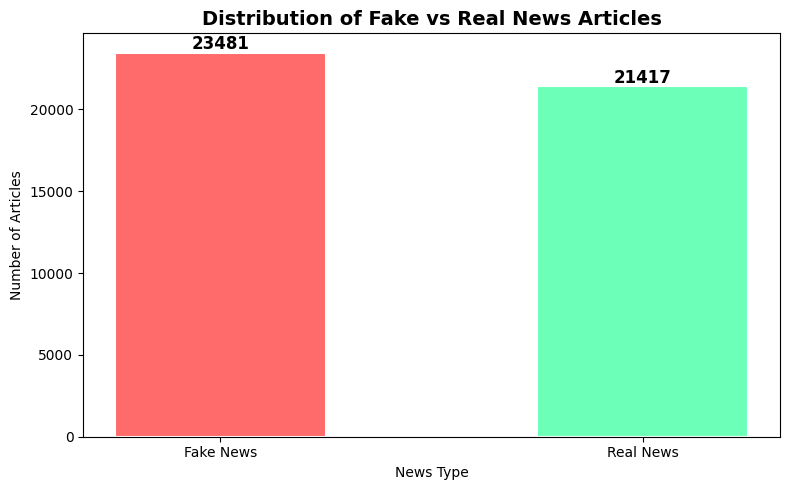

Dataset is balanced: 23481 fake vs 21417 real


In [4]:
# Visualize the dataset distribution
plt.figure(figsize=(8, 5))
colors = ['#ff6b6b', '#6bffb8']
labels = ['Fake News', 'Real News']
sizes = [len(fake), len(real)]

plt.bar(labels, sizes, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
plt.title('Distribution of Fake vs Real News Articles', fontsize=14, fontweight='bold')
plt.ylabel('Number of Articles')
plt.xlabel('News Type')

for i, v in enumerate(sizes):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
print(f"Dataset is balanced: {len(fake)} fake vs {len(real)} real")

In [5]:
# Text preprocessing and feature extraction
data["content"] = data["title"] + " " + data["text"]

X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# TF-IDF Vectorization
print("\nApplying TF-IDF Vectorization...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_vec.shape}")
print("✅ TF-IDF Vectorization complete!")

Training samples: 35918
Testing samples: 8980

Applying TF-IDF Vectorization...
Feature matrix shape: (35918, 5000)
✅ TF-IDF Vectorization complete!


In [6]:
# Train the model
print("Training Logistic Regression model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
print("✅ Model training complete!")

# Evaluate the model
predictions = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, predictions)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions, target_names=["Fake News", "Real News"]))

Training Logistic Regression model...
✅ Model training complete!

Model Accuracy: 98.67%

Detailed Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.99      4710
   Real News       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



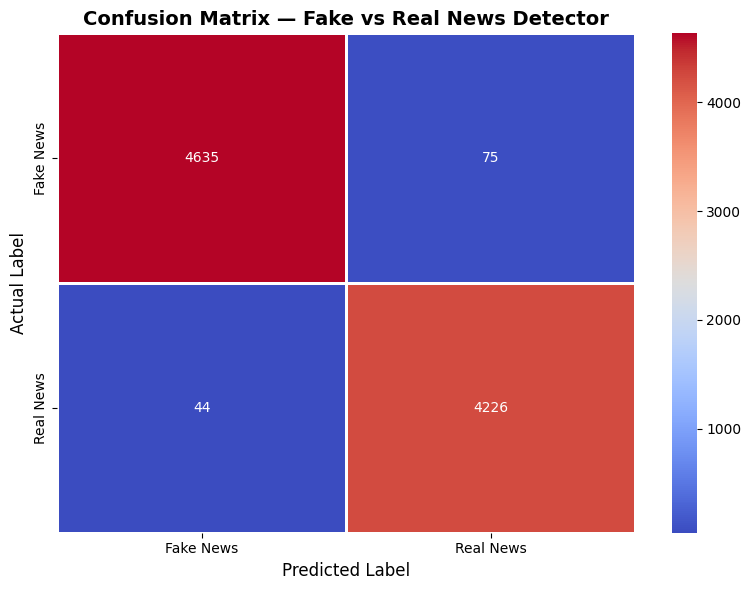

Correctly predicted Fake: 4635
Correctly predicted Real: 4226
Wrong predictions: 119


In [7]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'],
            linewidths=2, linecolor='white')

plt.title('Confusion Matrix — Fake vs Real News Detector', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Correctly predicted Fake: {cm[0][0]}")
print(f"Correctly predicted Real: {cm[1][1]}")
print(f"Wrong predictions: {cm[0][1] + cm[1][0]}")

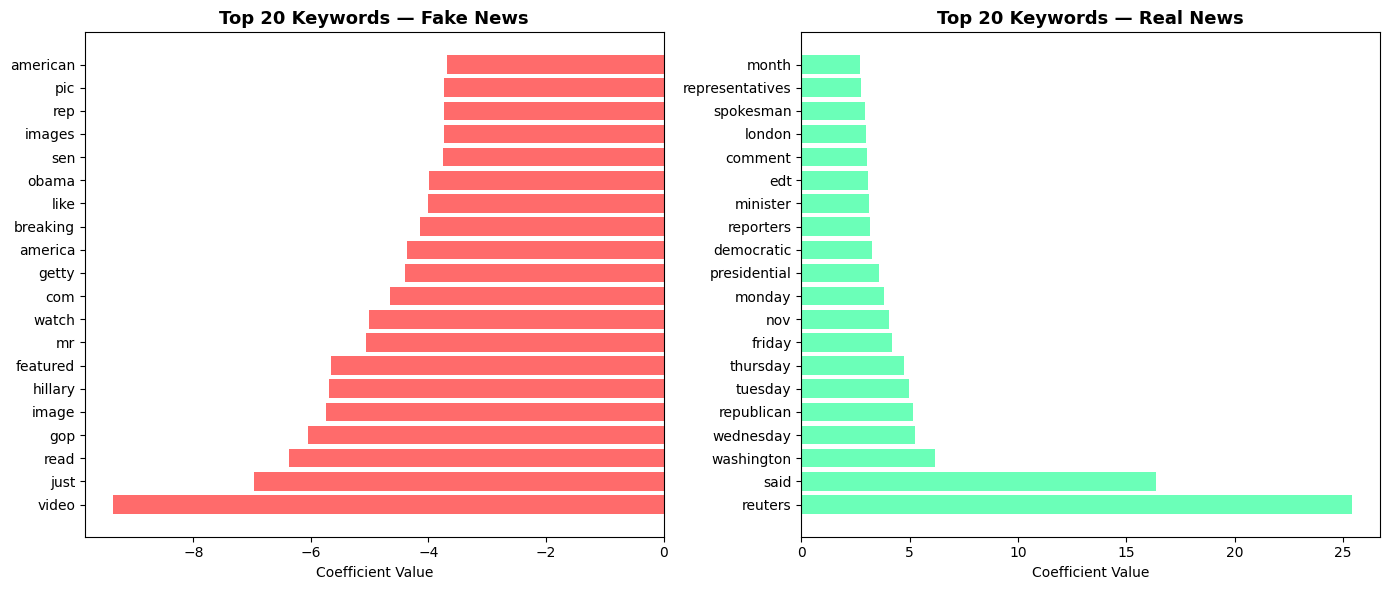

Fake news top words: ['video', 'just', 'read', 'gop', 'image']
Real news top words: ['reuters', 'said', 'washington', 'wednesday', 'republican']


In [8]:
# Top keywords that indicate Fake vs Real news
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake_idx = coefficients.argsort()[:20]
top_real_idx = coefficients.argsort()[-20:][::-1]

top_fake_words = [feature_names[i] for i in top_fake_idx]
top_real_words = [feature_names[i] for i in top_real_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(top_fake_words, coefficients[top_fake_idx], color='#ff6b6b')
ax1.set_title('Top 20 Keywords — Fake News', fontsize=13, fontweight='bold')
ax1.set_xlabel('Coefficient Value')

ax2.barh(top_real_words, coefficients[top_real_idx], color='#6bffb8')
ax2.set_title('Top 20 Keywords — Real News', fontsize=13, fontweight='bold')
ax2.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

print("Fake news top words:", top_fake_words[:5])
print("Real news top words:", top_real_words[:5])

In [9]:
# Test with custom headlines
test_headlines = [
    "U.S. appeals court rejects challenge to Trump travel ban",
    "Trump signs tax, government spending bills into law",
    "Hillary Clinton arrested for treason by FBI agents",
    "Vaccines contain microchips to track American citizens",
    "U.S. House approves $81 billion for disaster aid",
    "Obama admitted he was born in Kenya to close friends"
]

print("=" * 60)
print("LIVE PREDICTIONS ON SAMPLE HEADLINES")
print("=" * 60)

for headline in test_headlines:
    vec = vectorizer.transform([headline])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    
    if pred == 1:
        label = "✅ REAL NEWS"
        conf = round(proba[1] * 100, 1)
    else:
        label = "❌ FAKE NEWS"
        conf = round(proba[0] * 100, 1)
    
    print(f"\n📰 {headline[:55]}...")
    print(f"   Prediction: {label} (Confidence: {conf}%)")

print("\n" + "=" * 60)

LIVE PREDICTIONS ON SAMPLE HEADLINES

📰 U.S. appeals court rejects challenge to Trump travel ba...
   Prediction: ✅ REAL NEWS (Confidence: 64.3%)

📰 Trump signs tax, government spending bills into law...
   Prediction: ✅ REAL NEWS (Confidence: 68.9%)

📰 Hillary Clinton arrested for treason by FBI agents...
   Prediction: ❌ FAKE NEWS (Confidence: 97.7%)

📰 Vaccines contain microchips to track American citizens...
   Prediction: ❌ FAKE NEWS (Confidence: 95.8%)

📰 U.S. House approves $81 billion for disaster aid...
   Prediction: ❌ FAKE NEWS (Confidence: 54.0%)

📰 Obama admitted he was born in Kenya to close friends...
   Prediction: ❌ FAKE NEWS (Confidence: 87.6%)



In [10]:
# Project Summary
print("=" * 60)
print("       FAKE & REAL NEWS DETECTOR — PROJECT SUMMARY")
print("=" * 60)
print(f"""
PROJECT     : Fake & Real News Detector
DEVELOPER   : Soumya Ranjan Mishra
COLLEGE     : Rourkela Institute of Management Studies

DATASET     : Kaggle Fake & Real News Dataset
TOTAL DATA  : {len(data):,} articles
FAKE NEWS   : {len(fake):,} articles
REAL NEWS   : {len(real):,} articles

ALGORITHM   : Logistic Regression
VECTORIZER  : TF-IDF (Top 5,000 features)
ACCURACY    : {accuracy * 100:.2f}%
TRAIN SPLIT : 80% training / 20% testing

TECH STACK  : Python, Scikit-learn, Flask, HTML, CSS
DEPLOYMENT  : Render (Cloud Hosting)
LIVE LINK   : https://news-detector-mykz.onrender.com
GITHUB      : https://github.com/soumyamishra7/news-detector
""")
print("=" * 60)

       FAKE & REAL NEWS DETECTOR — PROJECT SUMMARY

PROJECT     : Fake & Real News Detector
DEVELOPER   : Soumya Ranjan Mishra
COLLEGE     : Rourkela Institute of Management Studies

DATASET     : Kaggle Fake & Real News Dataset
TOTAL DATA  : 44,898 articles
FAKE NEWS   : 23,481 articles
REAL NEWS   : 21,417 articles

ALGORITHM   : Logistic Regression
VECTORIZER  : TF-IDF (Top 5,000 features)
ACCURACY    : 98.67%
TRAIN SPLIT : 80% training / 20% testing

TECH STACK  : Python, Scikit-learn, Flask, HTML, CSS
DEPLOYMENT  : Render (Cloud Hosting)
LIVE LINK   : https://news-detector-mykz.onrender.com
GITHUB      : https://github.com/soumyamishra7/news-detector



In [11]:
# Model Comparison — Logistic Regression vs Naive Bayes vs SVM
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(max_iter=1000)
}

results = {}

for name, clf in models.items():
    print(f"Training {name}...")
    start = time.time()
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, preds) * 100
    elapsed = round(time.time() - start, 2)
    results[name] = acc
    print(f"✅ {name}: {acc:.2f}% accuracy (trained in {elapsed}s)")

print("\n🏆 Best Model:", max(results, key=results.get))

Training Logistic Regression...
✅ Logistic Regression: 98.67% accuracy (trained in 0.31s)
Training Naive Bayes...
✅ Naive Bayes: 92.88% accuracy (trained in 0.04s)
Training SVM...
✅ SVM: 99.33% accuracy (trained in 0.76s)

🏆 Best Model: SVM


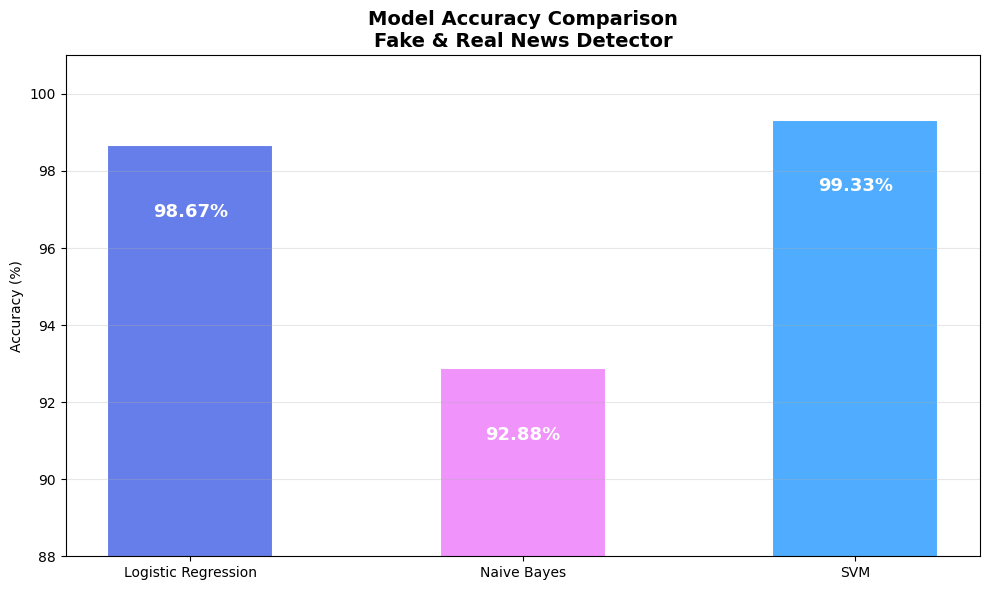

Model Comparison Summary:
  Logistic Regression: 98.67%
  Naive Bayes: 92.88%
  SVM: 99.33% 🏆 BEST


In [12]:
# Visualize model comparison
models_names = list(results.keys())
accuracies = list(results.values())
colors = ['#667eea', '#f093fb', '#4facfe']

plt.figure(figsize=(10, 6))
bars = plt.bar(models_names, accuracies, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
             f'{acc:.2f}%', ha='center', va='top', fontweight='bold',
             fontsize=13, color='white')

plt.title('Model Accuracy Comparison\nFake & Real News Detector', 
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim([88, 101])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Model Comparison Summary:")
for name, acc in results.items():
    star = " 🏆 BEST" if name == max(results, key=results.get) else ""
    print(f"  {name}: {acc:.2f}%{star}")

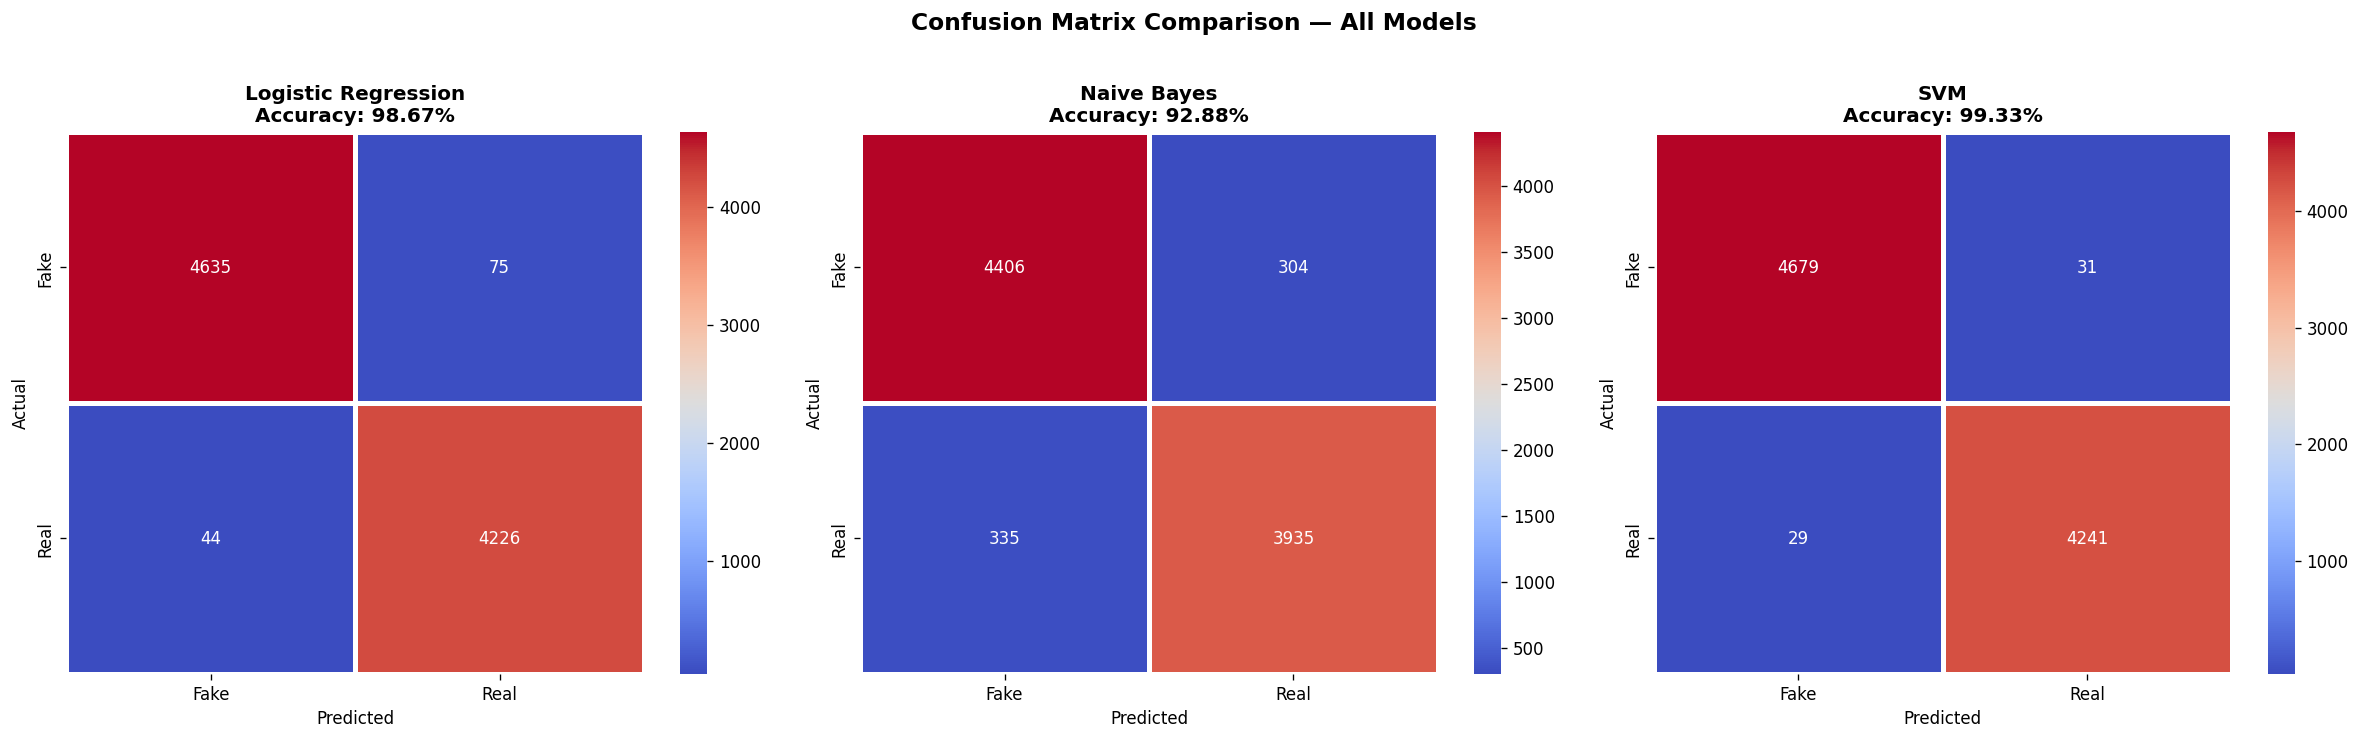

In [13]:
# Detailed comparison of all 3 models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=120)

model_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(max_iter=1000)
}

for idx, (name, clf) in enumerate(model_list.items()):
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'],
                ax=axes[idx], linewidths=2, linecolor='white')
    
    acc = accuracy_score(y_test, preds) * 100
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.2f}%', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison — All Models', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print("Fake.csv shape:", fake.shape)
print("True.csv shape:", real.shape)
print("\nColumns:", list(fake.columns))
print("\nCombined total rows:", fake.shape[0] + real.shape[0])

Fake.csv shape: (23481, 4)
True.csv shape: (21417, 4)

Columns: ['title', 'text', 'subject', 'date']

Combined total rows: 44898


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 70)
print(f"{'Model':<22}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1-Score'}")
print("=" * 70)

for name, clf in model_list.items():
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds) * 100
    rec = recall_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100
    print(f"{name:<22}{acc:<12.2f}{prec:<12.2f}{rec:<12.2f}{f1:.2f}")

Model                 Accuracy    Precision   Recall      F1-Score
Logistic Regression   98.67       98.26       98.97       98.61
Naive Bayes           92.88       92.83       92.15       92.49
SVM                   99.33       99.27       99.32       99.30
